## Step 1: Imports & Loading

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

df = pd.read_csv('car_purchase_data.csv')
df.head()

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## Step 2: Splitting X and y

In [9]:
X = df.iloc[:, [2, 3]].values
y = df.iloc[:, 4].values

## Step 3: Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Step 4: Scaling

In [11]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Step 5: Model Training

In [12]:
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

## Step 6: Results

In [13]:
y_pred = classifier.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100}%")

[[65  3]
 [ 8 24]]
Accuracy: 89.0%


## Step 7: Visualization

/tmp/ipykernel_975/654463153.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


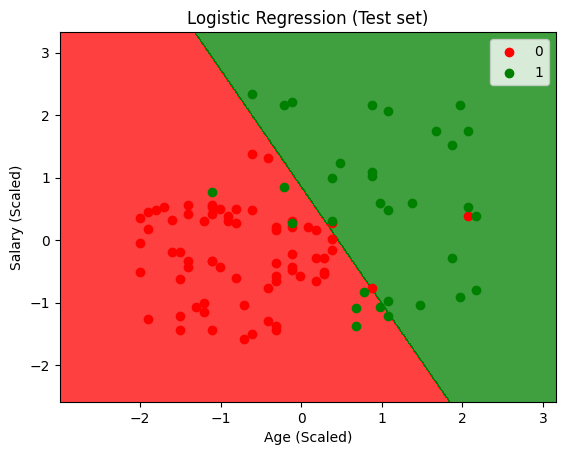

In [14]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)

plt.title('Logistic Regression (Test set)')
plt.xlabel('Age (Scaled)')
plt.ylabel('Salary (Scaled)')
plt.legend()
plt.show()

## Step 8: Reflection Questions

1.  **Probability to Classification logic:** The Sigmoid function is used in logistic regression to calculate a probability score. The model places the consumer in class 1 (Purchased) if how likely it is is 0.5 or above. They are placed in class 0 (Not Purchased) if it is less than 0.5.

2.  **Likely Customers:**
    The findings indicate that older consumers with greater incomes are most likely to buy the vehicle. It is shown that the graph's green "purchase" zone shifts toward the upper-right corner (High Age and High Salary).

3.  **Factors for Low Accuracy:**
    Because income numbers are thousands of times bigger than age values, failing to scale the data (StandardScaler) is a common cause of low accuracy. Because this model requires the straight-line boundary, accuracy may also be reduced if the connection between the variables isn't linear.